<a href="https://colab.research.google.com/github/pranjaldwivedii001-commits/Ad_Click_Prdiction_project/blob/main/churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
df1 = pd.read_csv("/content/client_data (1).csv")

In [81]:
df2 = pd.read_csv("/content/price_data (1).csv")

In [82]:
df1.columns

Index(['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'date_activ', 'date_end', 'date_modif_prod', 'date_renewal',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn'],
      dtype='object')

In [83]:
df1.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [84]:
df2.columns

Index(['id', 'price_date', 'price_off_peak_var', 'price_peak_var',
       'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix',
       'price_mid_peak_fix'],
      dtype='object')

In [85]:
df2.shape

(132517, 8)

In [86]:
df2.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [87]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [88]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132517 entries, 0 to 132516
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  132517 non-null  object 
 1   price_date          132516 non-null  object 
 2   price_off_peak_var  132516 non-null  float64
 3   price_peak_var      132516 non-null  float64
 4   price_mid_peak_var  132516 non-null  float64
 5   price_off_peak_fix  132516 non-null  float64
 6   price_peak_fix      132516 non-null  float64
 7   price_mid_peak_fix  132516 non-null  float64
dtypes: float64(6), object(2)
memory usage: 8.1+ MB


In [89]:
df1.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [90]:
df2.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,132516.000000,132516.000000,132516.000000,132516.000000,132516.000000,132516.000000
mean,0.141076,0.054671,0.030671,43.338548,10.669088,6.444248
std,0.025103,0.049941,0.036359,5.386480,12.843503,7.782021
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101781,0.072612,44.444710,24.339581,16.226389
max,0.280700,0.181480,0.114102,59.444710,36.490692,17.458221


In [91]:
df1['churn'].value_counts()

,count
churn,
0,13187
1,1419


In [92]:
df1.shape , df2.shape

((14606, 26), (132517, 8))

In [93]:
new_df = pd.merge(df1,df2,on= 'id')

In [94]:
new_df.shape

(119989, 33)

In [95]:
new_df['churn'].value_counts()

,count
churn,
0,107867
1,12122


In [96]:
new_df.isnull().sum().sum()

np.int64(0)

In [97]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119989 entries, 0 to 119988
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              119989 non-null  object 
 1   channel_sales                   119989 non-null  object 
 2   cons_12m                        119989 non-null  int64  
 3   cons_gas_12m                    119989 non-null  int64  
 4   cons_last_month                 119989 non-null  int64  
 5   date_activ                      119989 non-null  object 
 6   date_end                        119989 non-null  object 
 7   date_modif_prod                 119989 non-null  object 
 8   date_renewal                    119989 non-null  object 
 9   forecast_cons_12m               119989 non-null  float64
 10  forecast_cons_year              119989 non-null  int64  
 11  forecast_discount_energy        119989 non-null  float64
 12  forecast_meter_r

In [98]:
new_df['churn'].value_counts()

,count
churn,
0,107867
1,12122


In [99]:
new_df['has_gas'] = new_df['has_gas'].map({"t": 0 ,"f":1})

In [100]:
new_df.shape

(119989, 33)

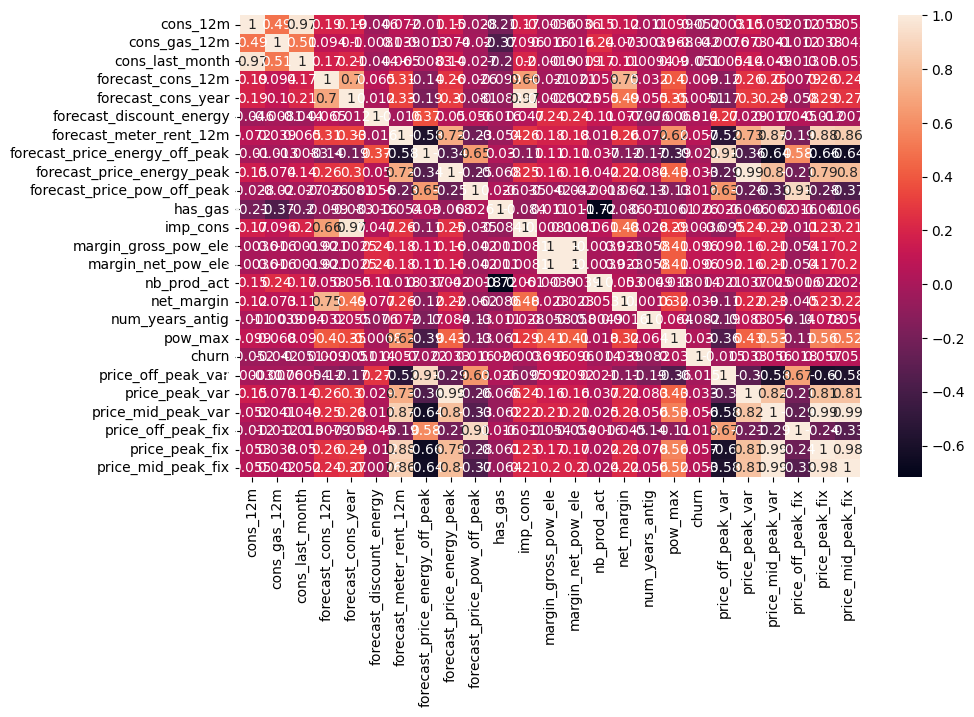

In [101]:
plt.figure(figsize=(10,6))
sns.heatmap(data=new_df.corr(numeric_only=True), annot=True)
plt.show()

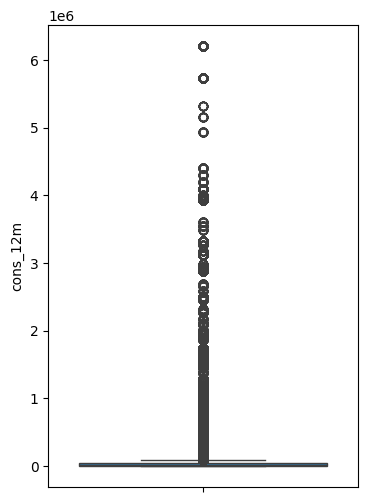

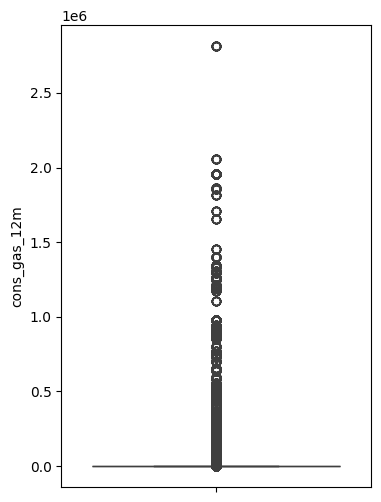

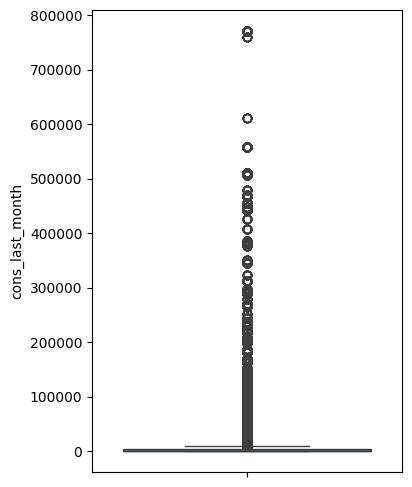

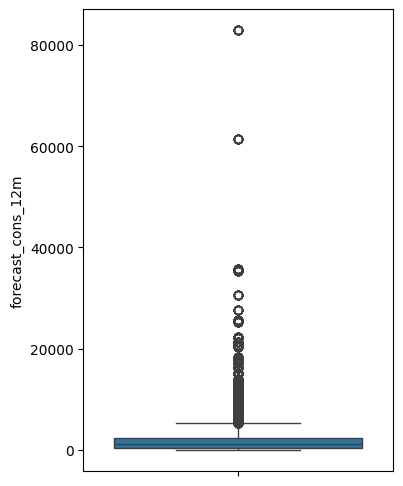

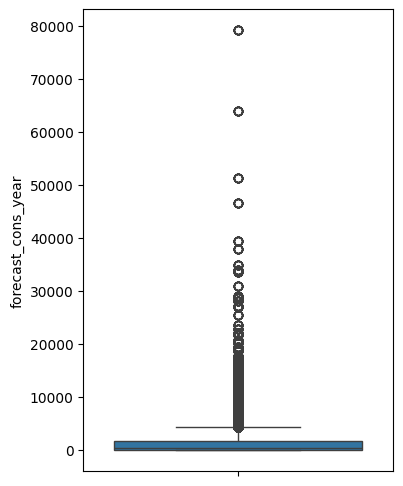

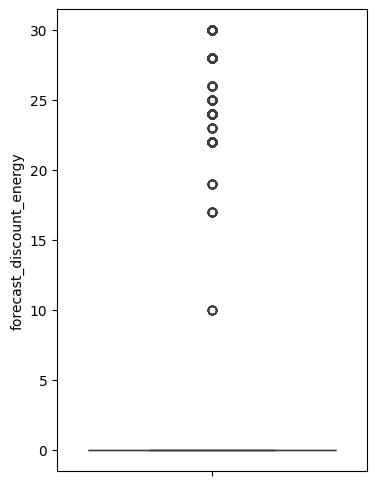

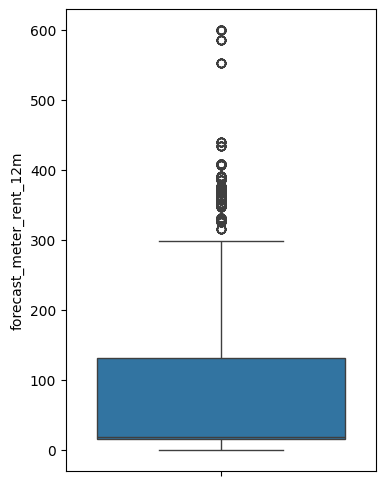

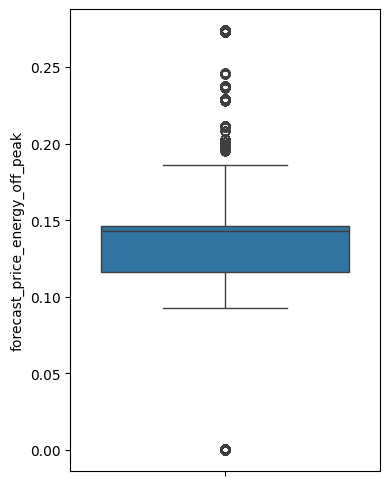

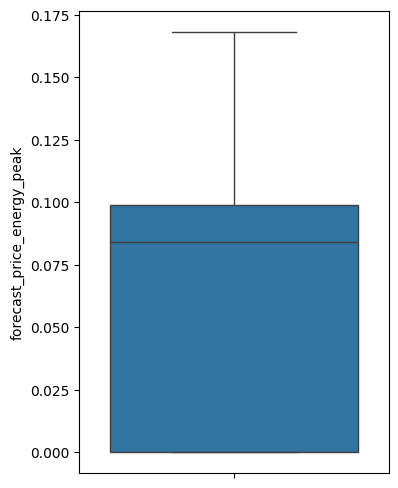

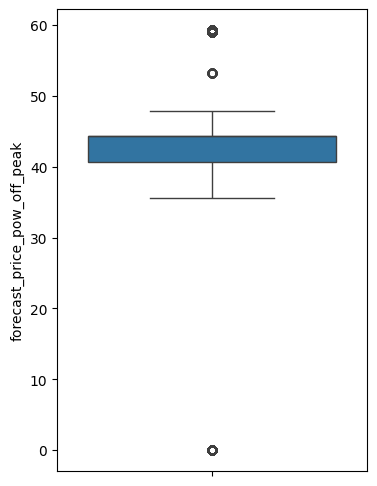

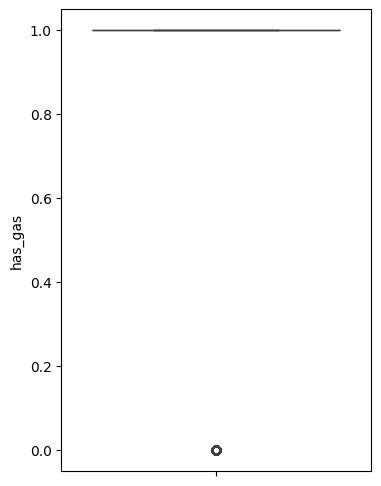

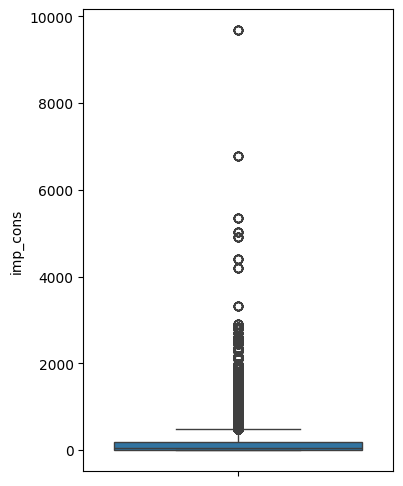

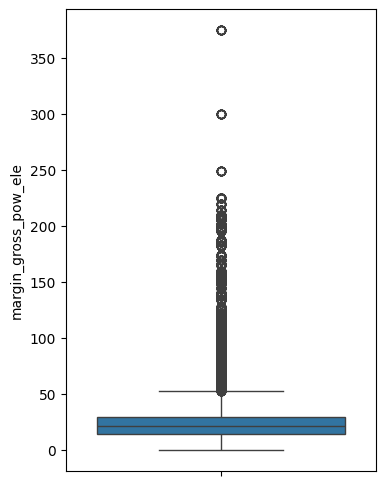

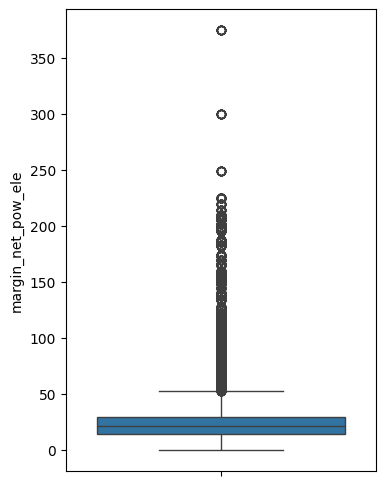

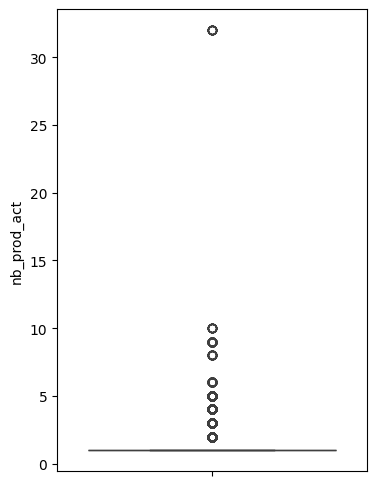

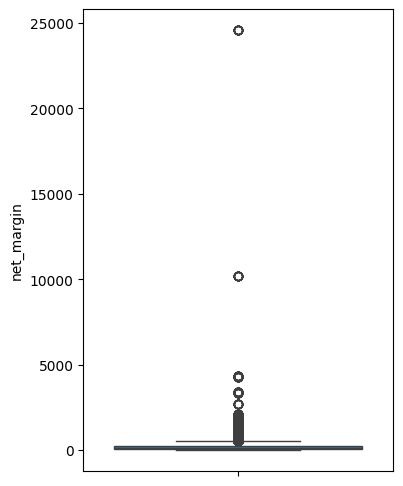

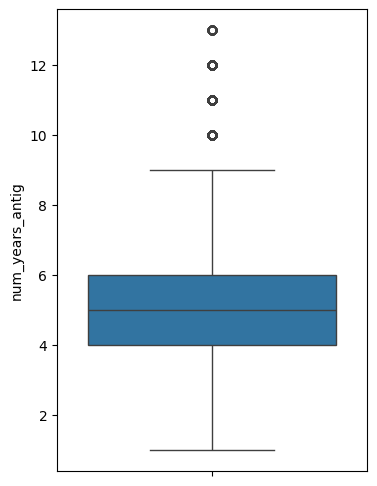

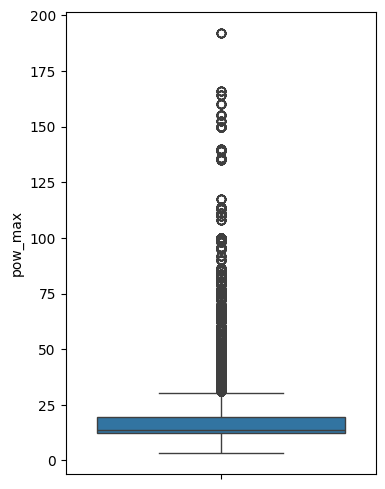

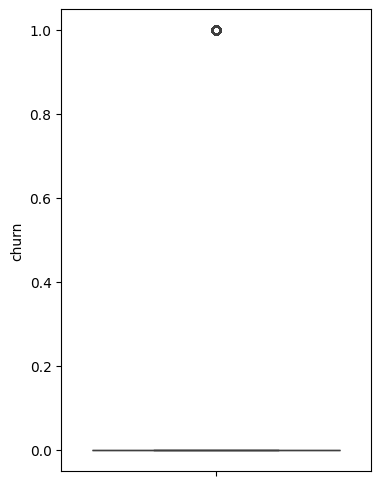

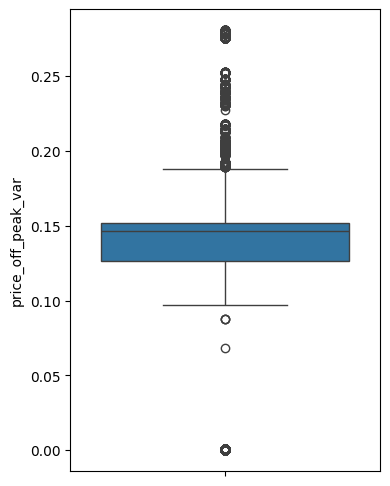

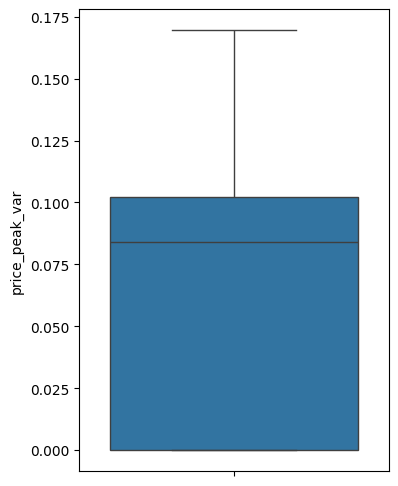

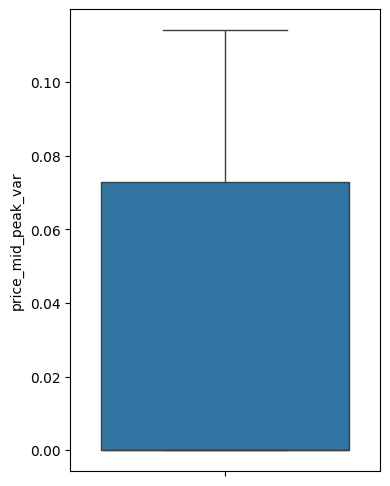

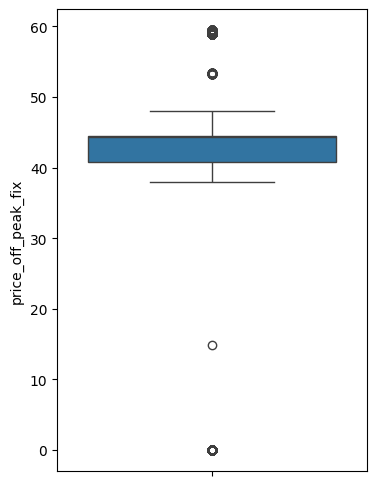

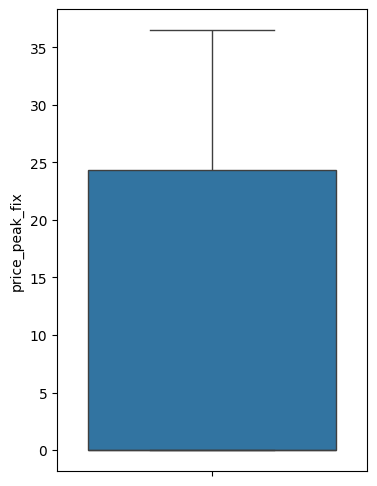

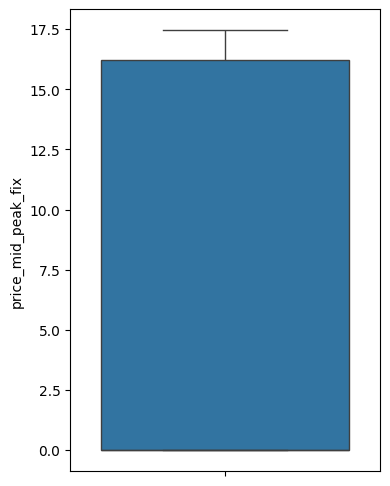

In [123]:
num_col = new_df.select_dtypes(include=np.number).columns.tolist()
for col in num_col:
  plt.figure(figsize=(4,6))
  sns.boxplot(new_df[col])
  plt.show()

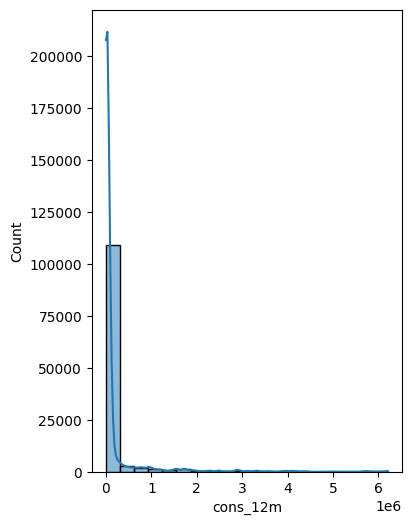

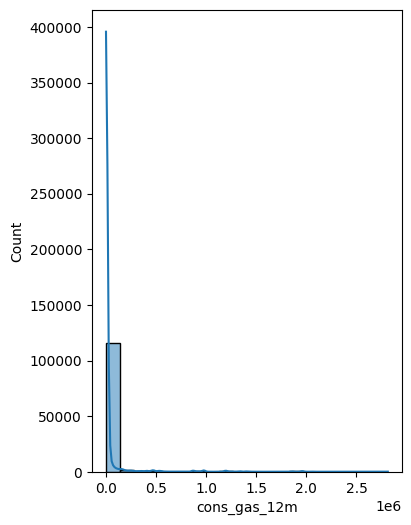

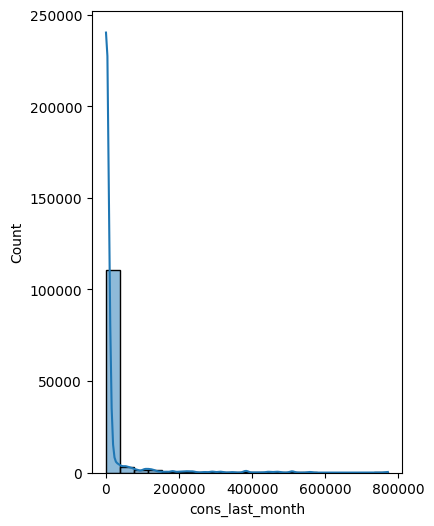

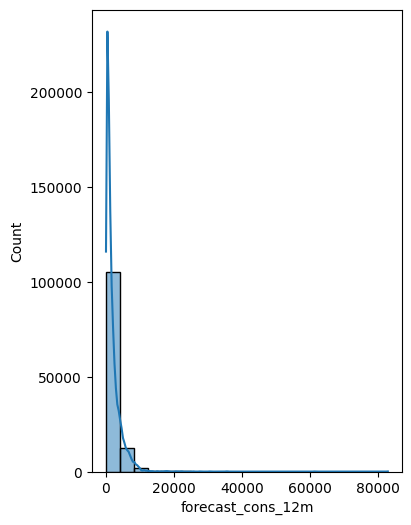

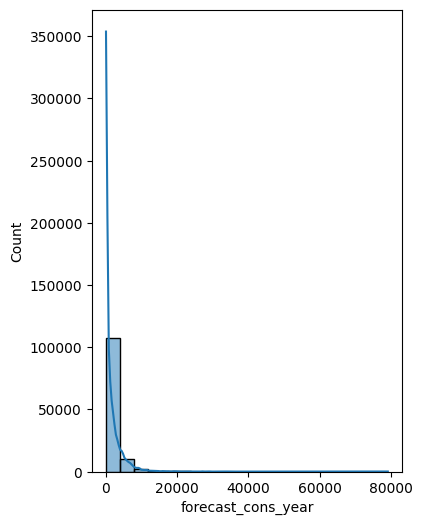

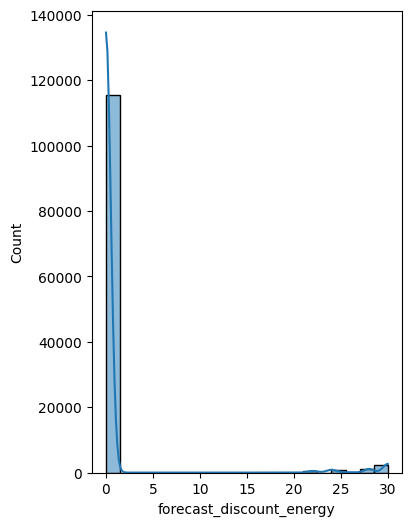

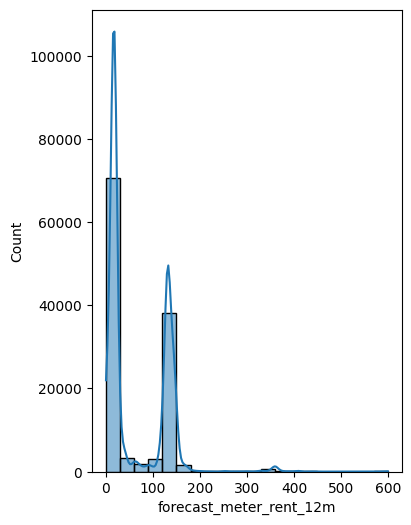

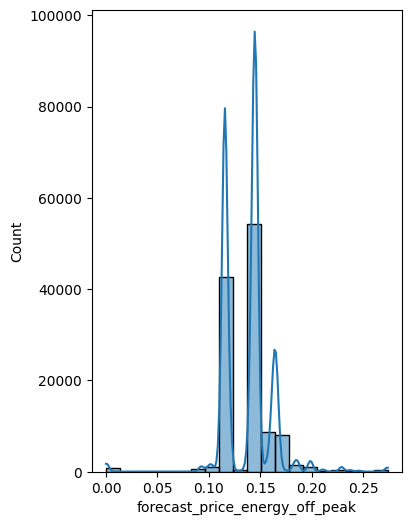

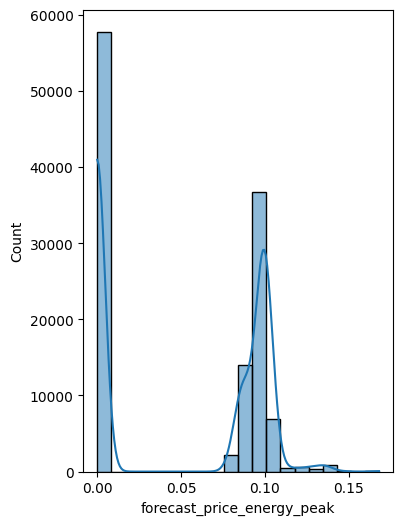

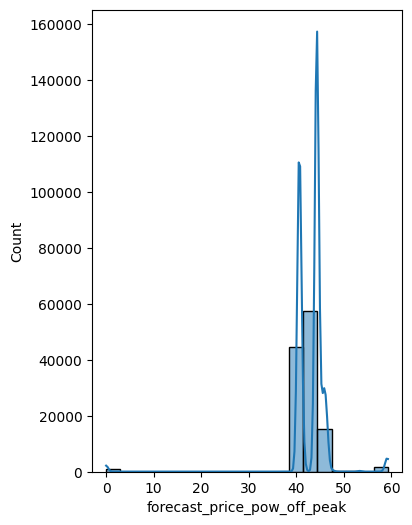

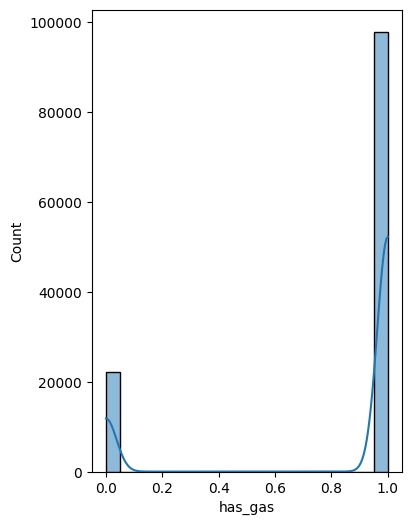

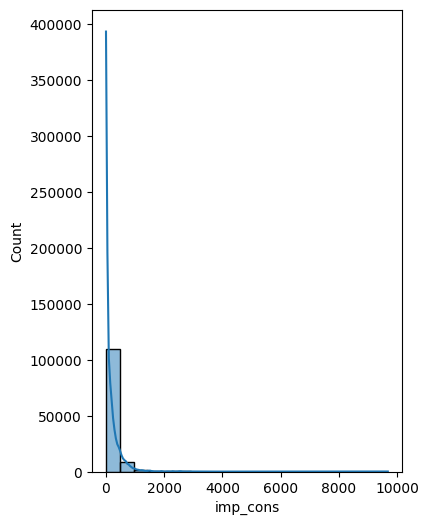

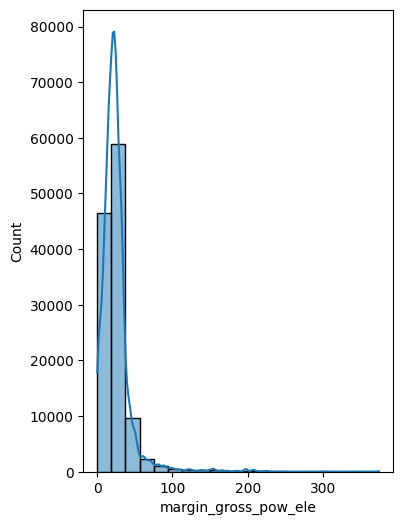

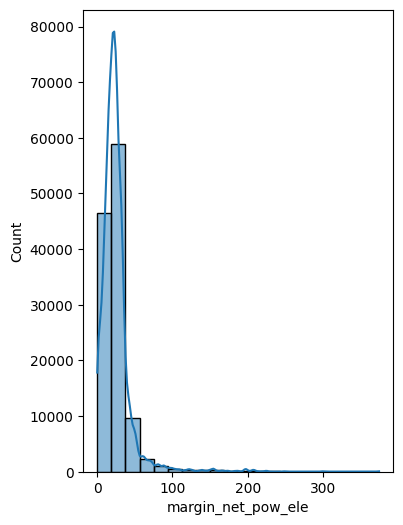

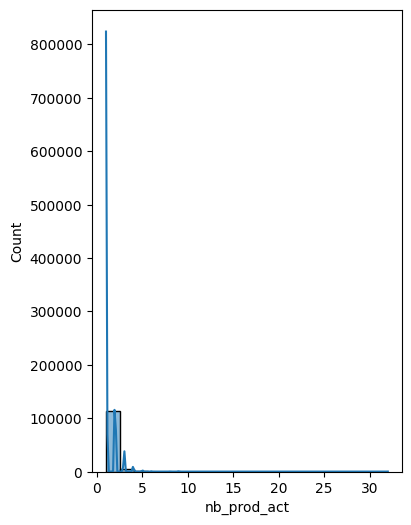

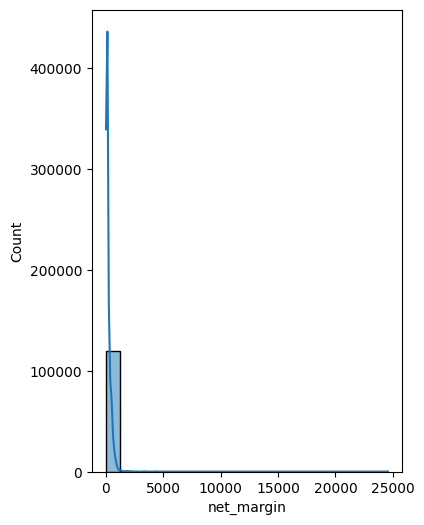

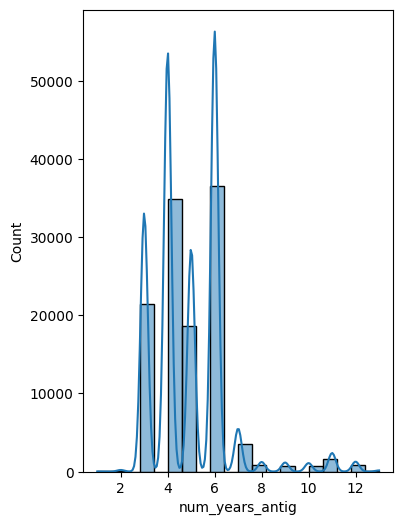

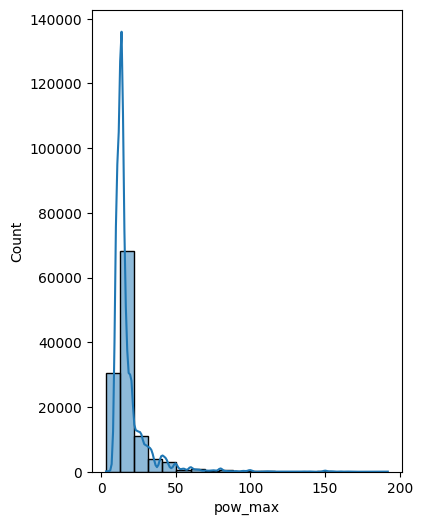

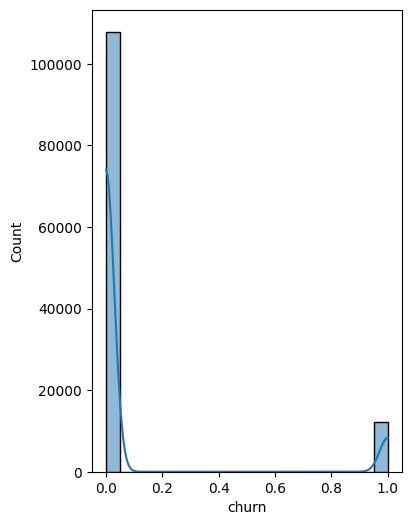

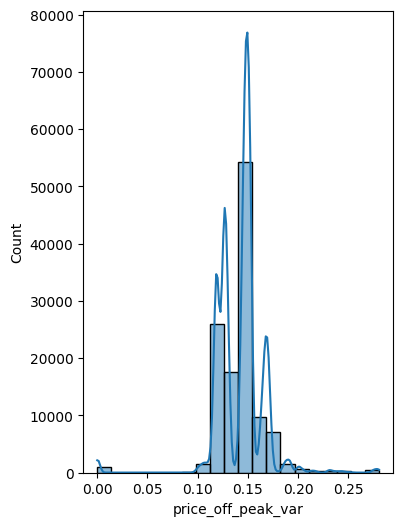

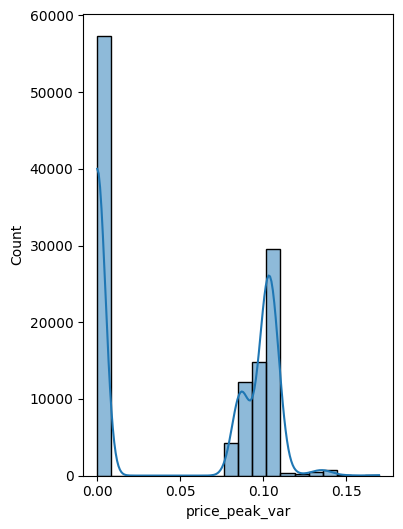

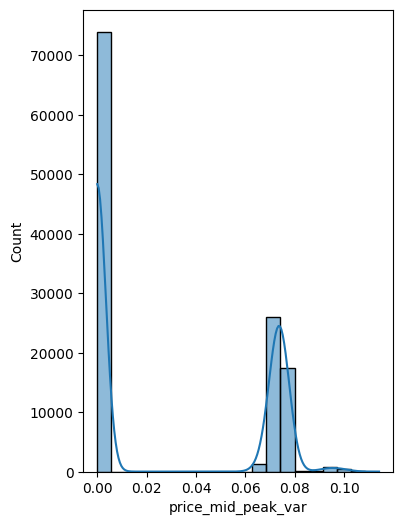

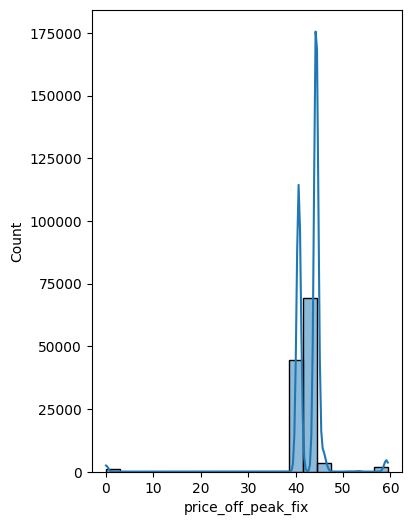

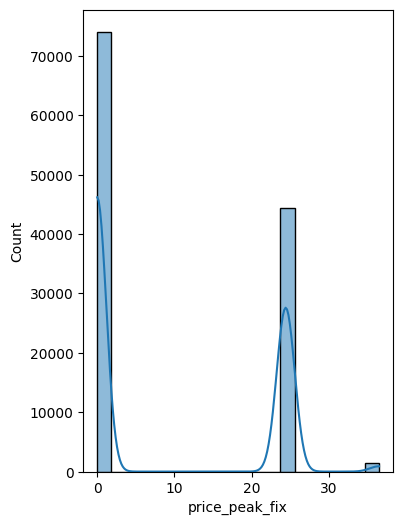

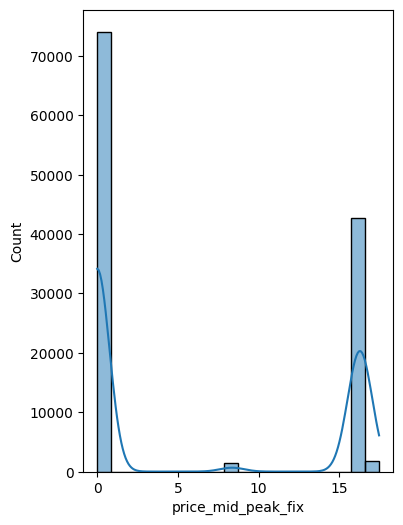

In [127]:
num_col = new_df.select_dtypes(include=np.number).columns.tolist()
for col in num_col:
  plt.figure(figsize=(4,6))
  sns.histplot(new_df[col],kde=True,bins=20)
  plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

In [ ]:
columns_to_drop = ['id', 'channel_sales', 'date_activ', 'date_end', 'date_modif_prod', 'date_renewal', 'origin_up', 'price_date']
new_df_processed = new_df.drop(columns=columns_to_drop)

print("Dropped non-numeric and date columns from new_data.")
display(new_df_processed.head())

In [ ]:
new_df_processed.shape

In [ ]:
X = new_df_processed.drop(columns='churn')
y = new_df_processed['churn']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

In [ ]:
from imblearn.over_sampling import SMOTE


In [103]:
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer

# Impute missing values before applying SMOTE
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_imputed, y_train)

In [104]:
X_train_res.shape , y_train_res.shape ,X_train_imputed.shape , y_train.shape ,new_df.shape , new_df_processed.shape

((158070, 24), (158070,), (88014, 24), (88014,), (119989, 33), (110018, 25))

In [105]:
from sklearn.preprocessing import StandardScaler

# Initialize and fit scaler on the SMOTE-resampled training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)

# Apply the same imputer to X_test that was fitted on X_train
# The 'imputer' object is available from the previous cell (6emtWLIedI4x)
X_test_imputed = imputer.transform(X_test)

# Transform the imputed test data using the fitted scaler
X_test_scaled = scaler.fit_transform(X_test_imputed)

print("Data scaled after SMOTE.")
print(f"Shape of scaled X_train_res: {X_train_scaled.shape}")
print(f"Shape of scaled X_test: {X_test_scaled.shape}")

Data scaled after SMOTE.
Shape of scaled X_train_res: (158070, 24)
Shape of scaled X_test: (22004, 24)


In [106]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest on scaled and SMOTE-resampled data
rf_model_manual = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_manual.fit(X_train_scaled, y_train_res)

print("RandomForestClassifier trained on manually SMOTE-resampled and scaled data.")

RandomForestClassifier trained on manually SMOTE-resampled and scaled data.


In [107]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions on the scaled test data
y_pred_manual = rf_model_manual.predict(X_test_scaled)

# Evaluate the model
accuracy_manual = accuracy_score(y_test, y_pred_manual)
print(f"\nAccuracy of the RandomForestClassifier with manual SMOTE and scaling: {accuracy_manual:.4f}")
print("\nClassification Report for RandomForestClassifier with manual SMOTE and scaling:")
print(classification_report(y_test, y_pred_manual))


Accuracy of the RandomForestClassifier with manual SMOTE and scaling: 0.9050

Classification Report for RandomForestClassifier with manual SMOTE and scaling:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     19781
           1       0.92      0.06      0.12      2223

    accuracy                           0.90     22004
   macro avg       0.91      0.53      0.54     22004
weighted avg       0.91      0.90      0.87     22004



In [108]:
accuracy_manual = accuracy_score(y_test, y_pred_manual)
accuracy_manual

0.9049718233048537

In [109]:
train_pred = rf_model_manual.predict(X_train_scaled)
accuracy_score(train_pred,y_train_res)

1.0

In [110]:
y_test.value_counts()

,count
churn,
0,19781
1,2223


### Applying Logistic Regression

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver for small datasets and L1/L2 regularization
log_reg_model.fit(X_train_scaled, y_train_res)

print("Logistic Regression model trained.")

# Make predictions on the scaled test data
y_pred_log_reg = log_reg_model.predict(X_test_scaled)

# Evaluate the Logistic Regression model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
print(f"\nAccuracy of Logistic Regression: {accuracy_log_reg:.4f}")
print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression model trained.

Accuracy of Logistic Regression: 0.5454

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.94      0.53      0.68     19781
           1       0.14      0.71      0.24      2223

    accuracy                           0.55     22004
   macro avg       0.54      0.62      0.46     22004
weighted avg       0.86      0.55      0.63     22004



### Applying Decision Tree

In [112]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train Decision Tree model
dec_tree_model = DecisionTreeClassifier(random_state=42)
dec_tree_model.fit(X_train_scaled, y_train_res)

print("Decision Tree model trained.")

# Make predictions on the scaled test data
y_pred_dec_tree = dec_tree_model.predict(X_test_scaled)

# Evaluate the Decision Tree model
accuracy_dec_tree = accuracy_score(y_test, y_pred_dec_tree)
print(f"\nAccuracy of Decision Tree: {accuracy_dec_tree:.4f}")
print("\nClassification Report for Decision Tree:")
print(classification_report(y_test, y_pred_dec_tree))

Decision Tree model trained.

Accuracy of Decision Tree: 0.7356

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84     19781
           1       0.15      0.34      0.21      2223

    accuracy                           0.74     22004
   macro avg       0.53      0.56      0.52     22004
weighted avg       0.84      0.74      0.78     22004



### Applying XGBoost Classifier

In [113]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train XGBoost model
# Using 'use_label_encoder=False' and 'eval_metric' to suppress warnings
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train_res)

print("XGBoost model trained.")

# Make predictions on the scaled test data
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluate the XGBoost model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nAccuracy of XGBoost: {accuracy_xgb:.4f}")
print("\nClassification Report for XGBoost:")
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:35:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained.

Accuracy of XGBoost: 0.7666

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86     19781
           1       0.19      0.40      0.26      2223

    accuracy                           0.77     22004
   macro avg       0.56      0.60      0.56     22004
weighted avg       0.85      0.77      0.80     22004



Top 10 Most Important Features:
                           Feature  Importance
0                         cons_12m    0.090522
6          forecast_meter_rent_12m    0.088980
12            margin_gross_pow_ele    0.086517
13              margin_net_pow_ele    0.085705
15                      net_margin    0.082155
3                forecast_cons_12m    0.080510
2                  cons_last_month    0.060648
17                         pow_max    0.058002
7   forecast_price_energy_off_peak    0.055010
4               forecast_cons_year    0.044084


/tmp/ipykernel_8486/3418537804.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances_df.head(15), palette='viridis')


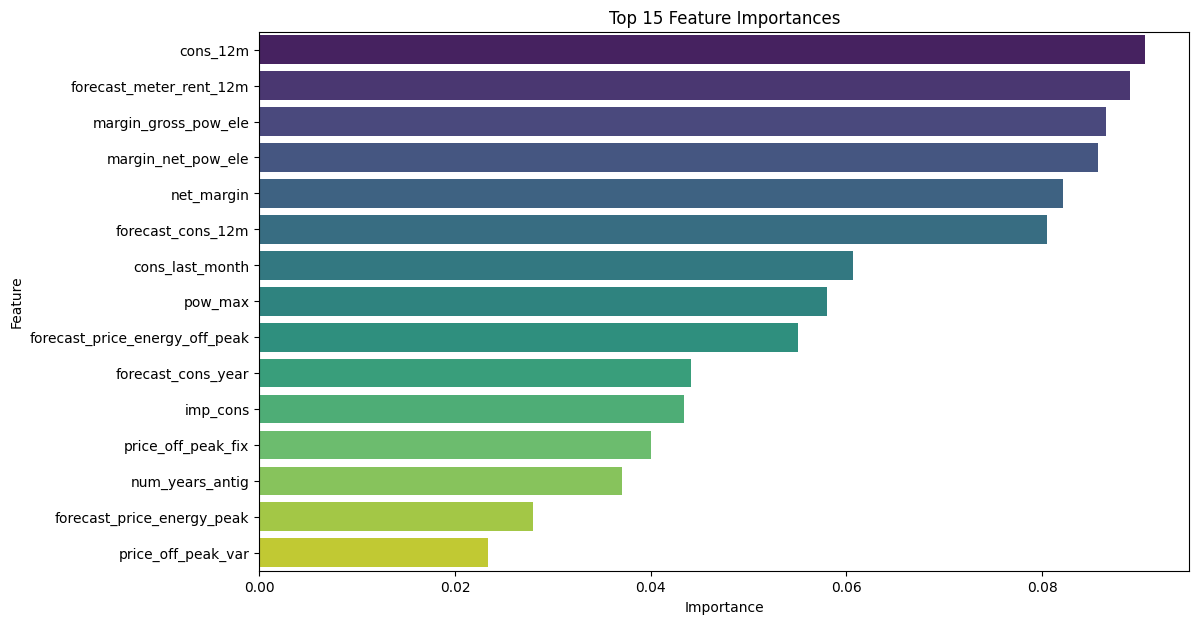


Selected Top 10 Features for retraining: ['cons_12m', 'forecast_meter_rent_12m', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin', 'forecast_cons_12m', 'cons_last_month', 'pow_max', 'forecast_price_energy_off_peak', 'forecast_cons_year']
Shape of X_train_selected: (158070, 10)
Shape of X_test_selected: (22004, 10)

RandomForestClassifier retrained with selected features.

Accuracy of the retrained model with selected features: 0.9032

Classification Report for the retrained model:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     19781
           1       0.86      0.05      0.09      2223

    accuracy                           0.90     22004
   macro avg       0.88      0.52      0.52     22004
weighted avg       0.90      0.90      0.86     22004


--- Summary of Feature Importance and Retrained Model Evaluation ---
Feature importance analysis identified the most influential factors for predicting churn.
The top 10 featu

In [114]:
feature_importances = rf_model_manual.feature_importances_
importances_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
importances_df = importances_df.sort_values(by='Importance', ascending=False)

# Display Top 10 Most Important Features
print("Top 10 Most Important Features:")
print(importances_df.head(10))

# Visualize Top 15 Feature Importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importances_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Select Top 10 Features
top_10_features = importances_df.head(10)['Feature'].tolist()
print(f"\nSelected Top 10 Features for retraining: {top_10_features}")

# --- FIX STARTS HERE ---
# Get the numerical indices of the selected features
original_feature_names = X.columns.tolist()
selected_indices = [original_feature_names.index(feat) for feat in top_10_features]

# Prepare Data for Retraining with Selected Features by slicing the NumPy arrays
X_train_selected = X_train_scaled[:, selected_indices]
X_test_selected = X_test_scaled[:, selected_indices]
# --- FIX ENDS HERE ---

print(f"Shape of X_train_selected: {X_train_selected.shape}")
print(f"Shape of X_test_selected: {X_test_selected.shape}")

# Retrain Model with Selected Features
rf_model_selected = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
# --- IMPORTANT: Use y_train_res here as X_train_selected is based on SMOTE-resampled data ---
rf_model_selected.fit(X_train_selected, y_train_res)
print("\nRandomForestClassifier retrained with selected features.")

# Make Predictions with the Retrained Model
y_pred_selected = rf_model_selected.predict(X_test_selected)

# Evaluate the Retrained Model
accuracy_selected = accuracy_score(y_test, y_pred_selected)
print(f"\nAccuracy of the retrained model with selected features: {accuracy_selected:.4f}")
print("\nClassification Report for the retrained model:")
print(classification_report(y_test, y_pred_selected))

# Final Task: Summarize the results
print("\n--- Summary of Feature Importance and Retrained Model Evaluation ---")
print("Feature importance analysis identified the most influential factors for predicting churn.")
print(f"The top 10 features selected for retraining were: {top_10_features}.")
print(f"The retrained model using these selected features achieved an accuracy of {accuracy_selected:.4f}.")


### Outlier Detection and Visualization for All Numeric Features

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def detect_and_visualize_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column} with Outliers ({len(outliers)} detected)')
    plt.xlabel(column)
    plt.show()

    if not outliers.empty:
        print(f"\nOutliers detected in '{column}':")
        display(outliers[[column, 'churn']].head())
    else:
        print(f"\nNo significant outliers detected in '{column}'.")

Analyzing outliers for 24 numeric columns...


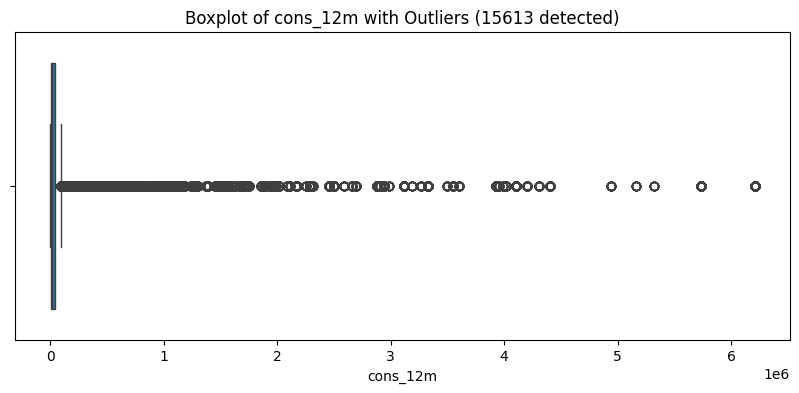


Outliers detected in 'cons_12m':


,cons_12m,churn
192,1856956,0
193,1856956,0
194,1856956,0
195,1856956,0
196,1856956,0


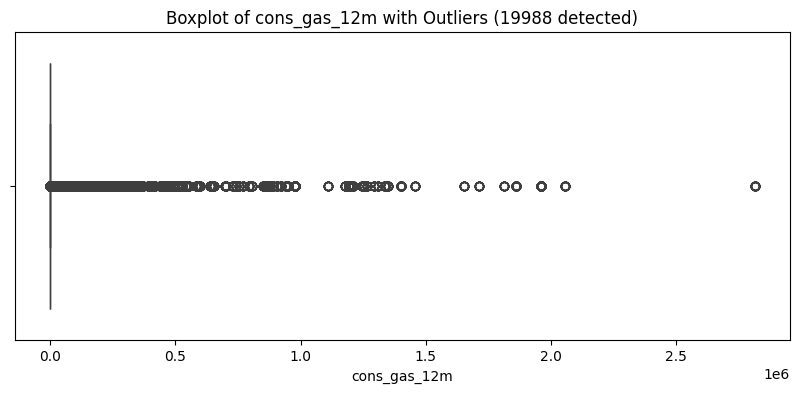


Outliers detected in 'cons_gas_12m':


,cons_gas_12m,churn
0,54946,1
1,54946,1
2,54946,1
3,54946,1
4,54946,1


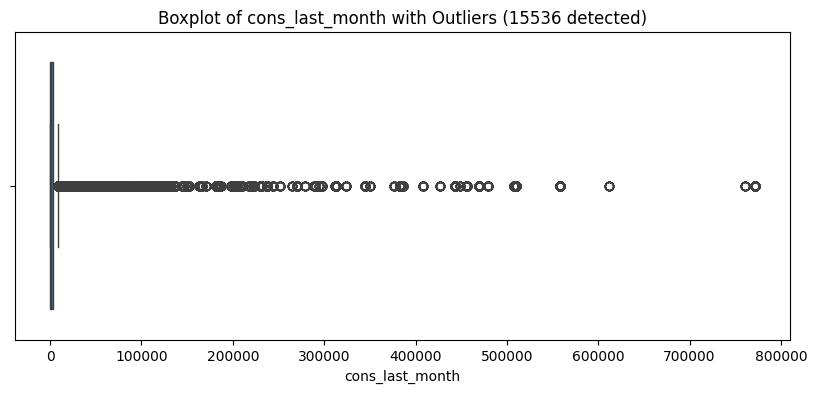


Outliers detected in 'cons_last_month':


,cons_last_month,churn
192,164355,0
193,164355,0
194,164355,0
195,164355,0
196,164355,0


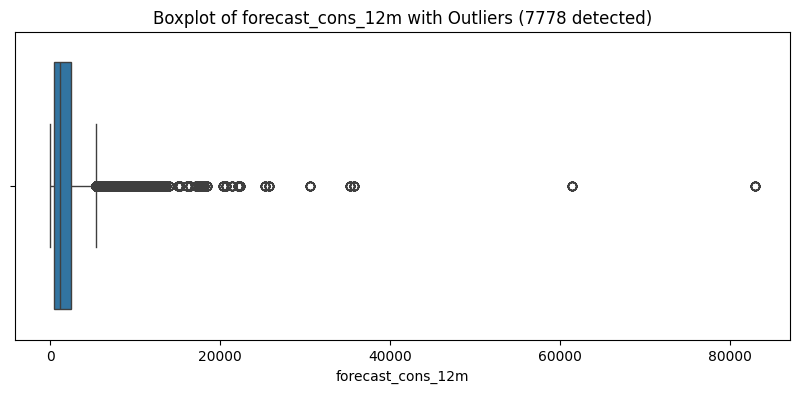


Outliers detected in 'forecast_cons_12m':


,forecast_cons_12m,churn
36,8069.28,1
37,8069.28,1
38,8069.28,1
39,8069.28,1
40,8069.28,1


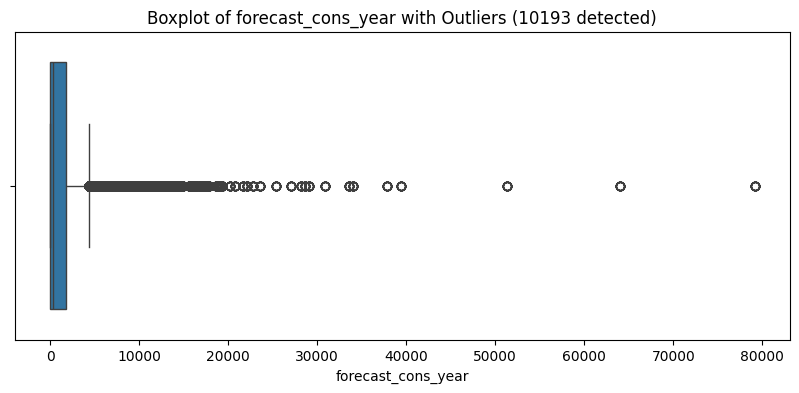


Outliers detected in 'forecast_cons_year':


,forecast_cons_year,churn
348,6094,1
349,6094,1
350,6094,1
351,6094,1
352,6094,1


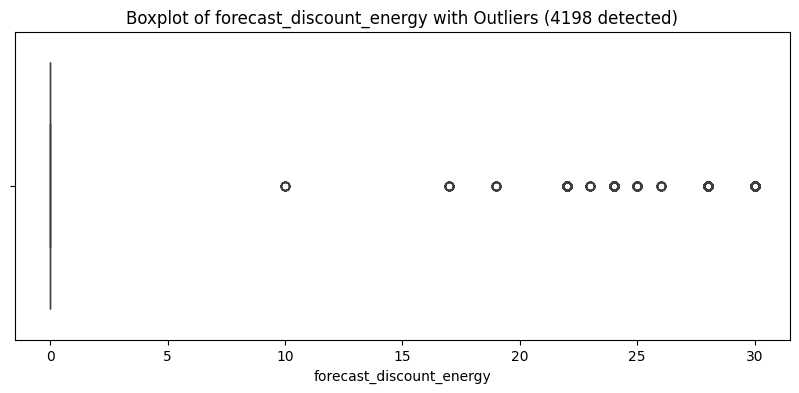


Outliers detected in 'forecast_discount_energy':


,forecast_discount_energy,churn
216,30.0,0
217,30.0,0
218,30.0,0
219,30.0,0
220,30.0,0


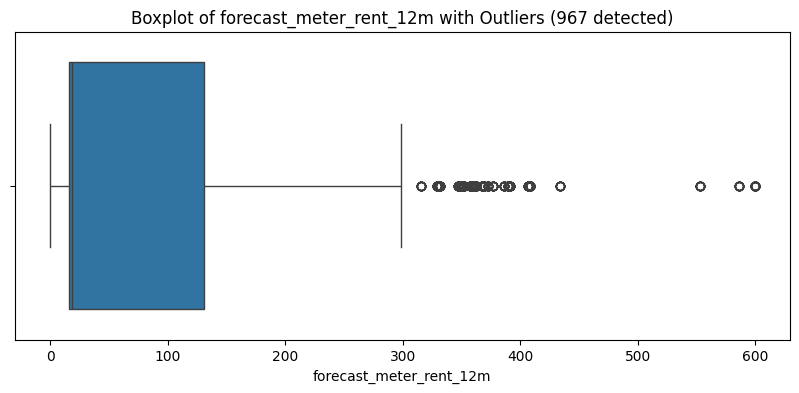


Outliers detected in 'forecast_meter_rent_12m':


,forecast_meter_rent_12m,churn
1440,359.25,0
1441,359.25,0
1442,359.25,0
1443,359.25,0
1444,359.25,0


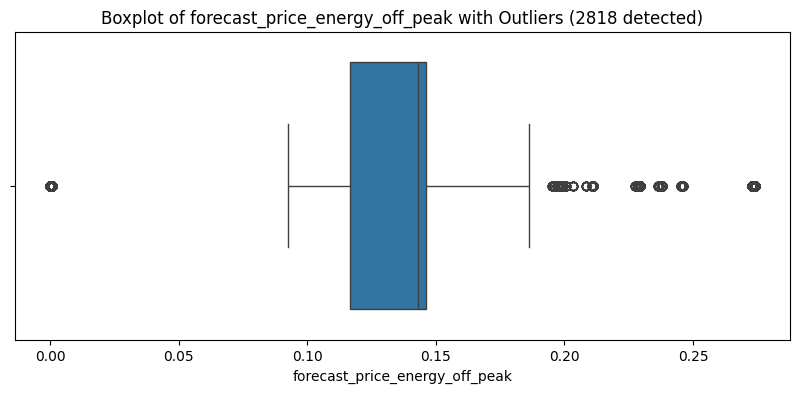


Outliers detected in 'forecast_price_energy_off_peak':


,forecast_price_energy_off_peak,churn
216,0.198096,0
217,0.198096,0
218,0.198096,0
219,0.198096,0
220,0.198096,0


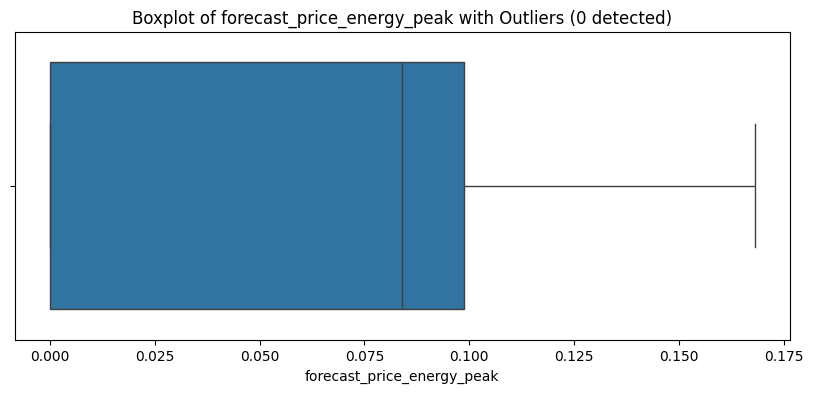


No significant outliers detected in 'forecast_price_energy_peak'.


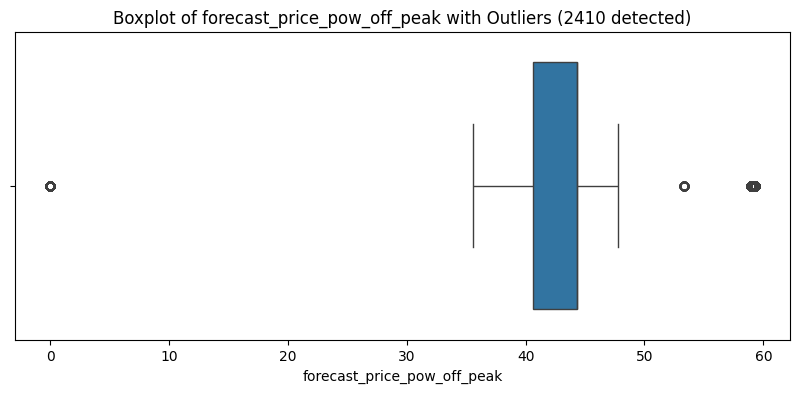


Outliers detected in 'forecast_price_pow_off_peak':


,forecast_price_pow_off_peak,churn
336,0.0,0
337,0.0,0
338,0.0,0
339,0.0,0
340,0.0,0


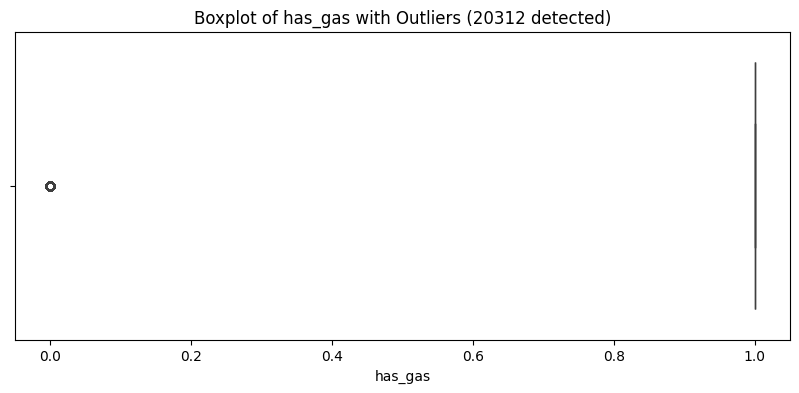


Outliers detected in 'has_gas':


,has_gas,churn
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


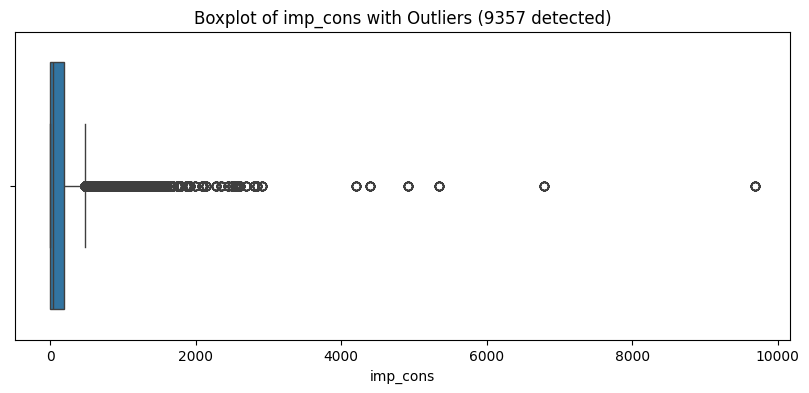


Outliers detected in 'imp_cons':


,imp_cons,churn
348,611.08,1
349,611.08,1
350,611.08,1
351,611.08,1
352,611.08,1


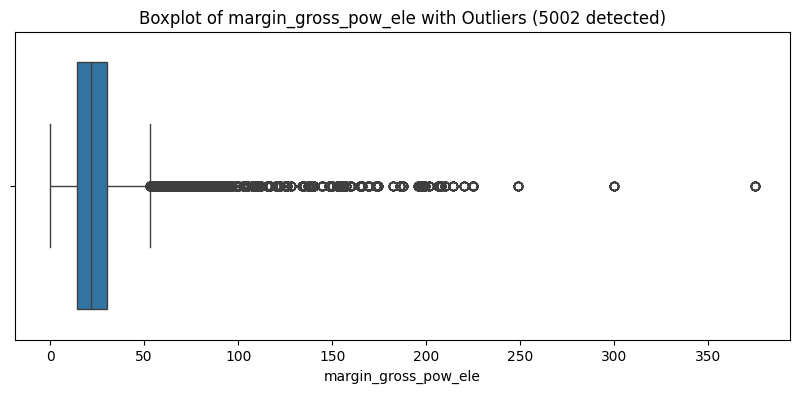


Outliers detected in 'margin_gross_pow_ele':


,margin_gross_pow_ele,churn
48,53.92,0
49,53.92,0
50,53.92,0
51,53.92,0
52,53.92,0


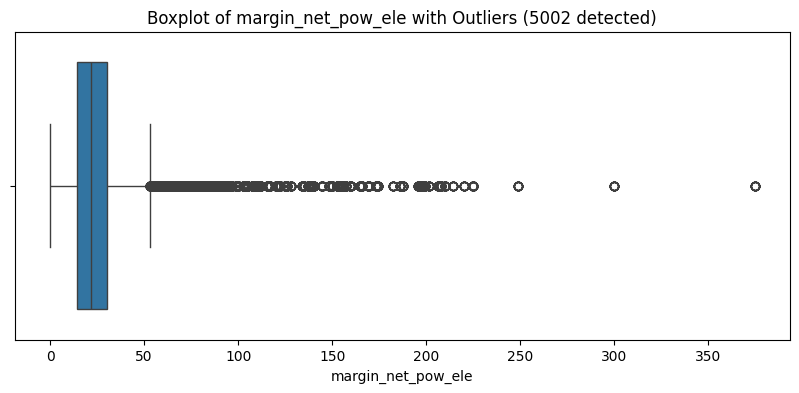


Outliers detected in 'margin_net_pow_ele':


,margin_net_pow_ele,churn
48,53.92,0
49,53.92,0
50,53.92,0
51,53.92,0
52,53.92,0


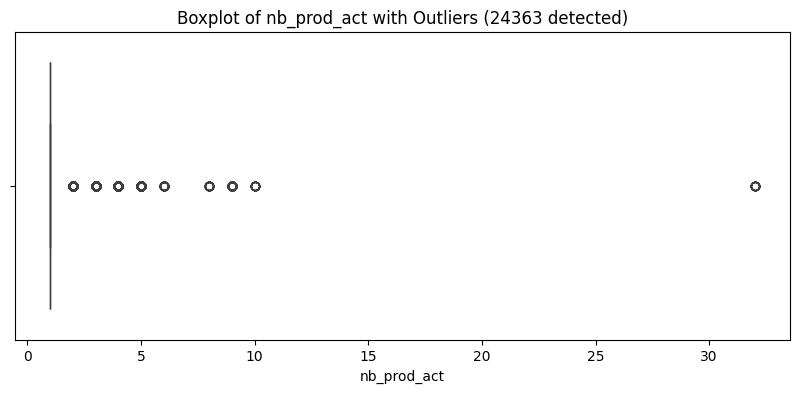


Outliers detected in 'nb_prod_act':


,nb_prod_act,churn
0,2,1
1,2,1
2,2,1
3,2,1
4,2,1


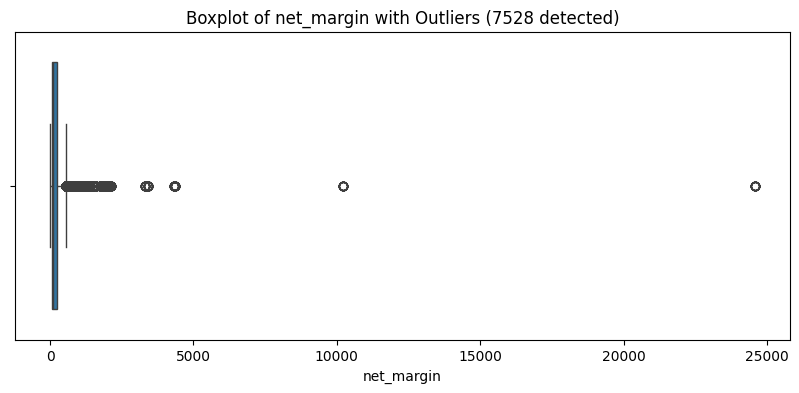


Outliers detected in 'net_margin':


,net_margin,churn
0,678.99,1
1,678.99,1
2,678.99,1
3,678.99,1
4,678.99,1


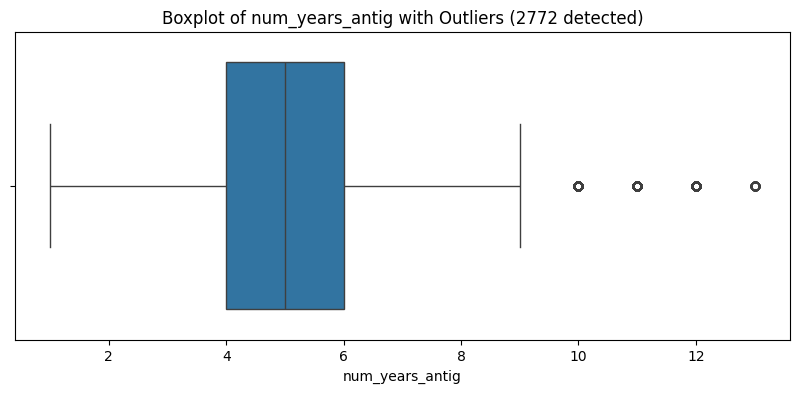


Outliers detected in 'num_years_antig':


,num_years_antig,churn
252,11,0
253,11,0
254,11,0
255,11,0
256,11,0


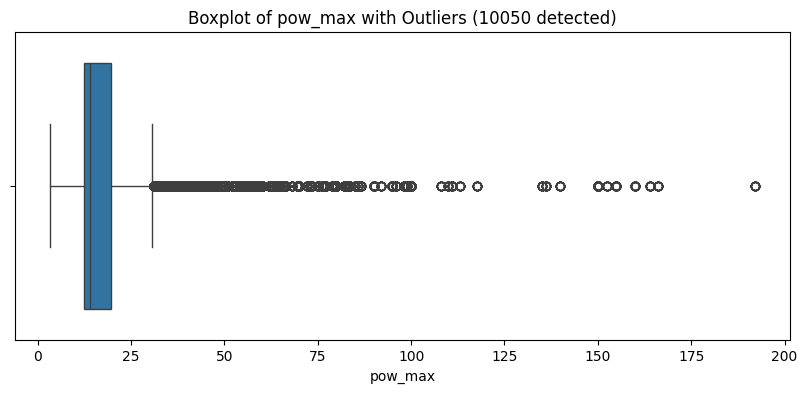


Outliers detected in 'pow_max':


,pow_max,churn
0,43.648,1
1,43.648,1
2,43.648,1
3,43.648,1
4,43.648,1


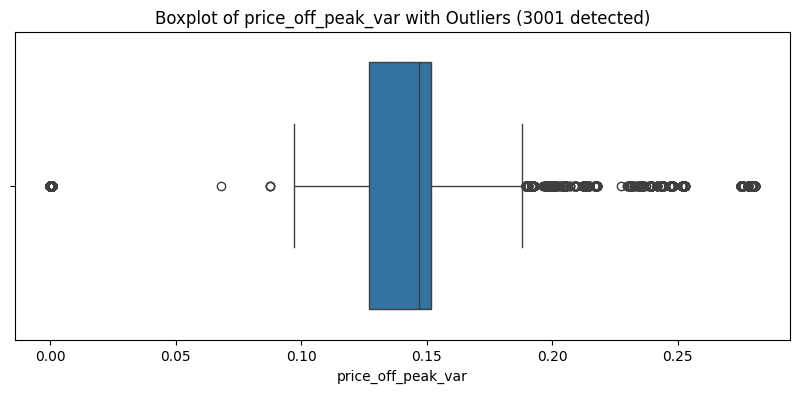


Outliers detected in 'price_off_peak_var':


,price_off_peak_var,churn
201,0.000000,0
202,0.000000,0
222,0.204604,0
223,0.200142,0
224,0.200142,0


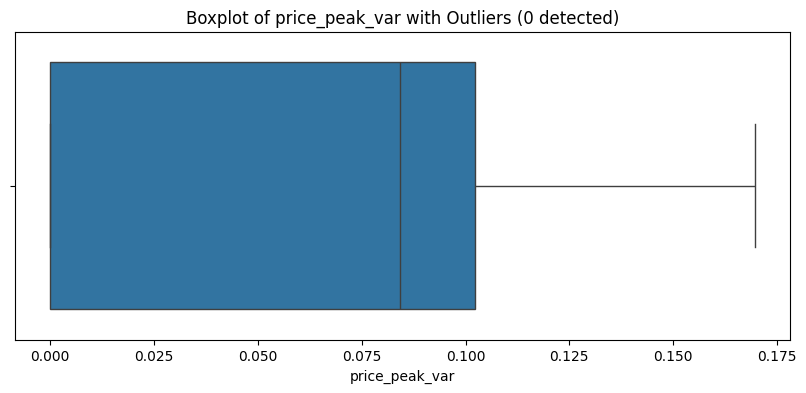


No significant outliers detected in 'price_peak_var'.


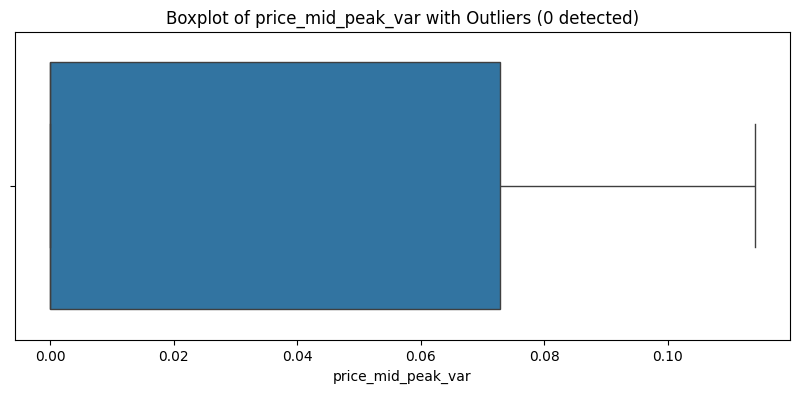


No significant outliers detected in 'price_mid_peak_var'.


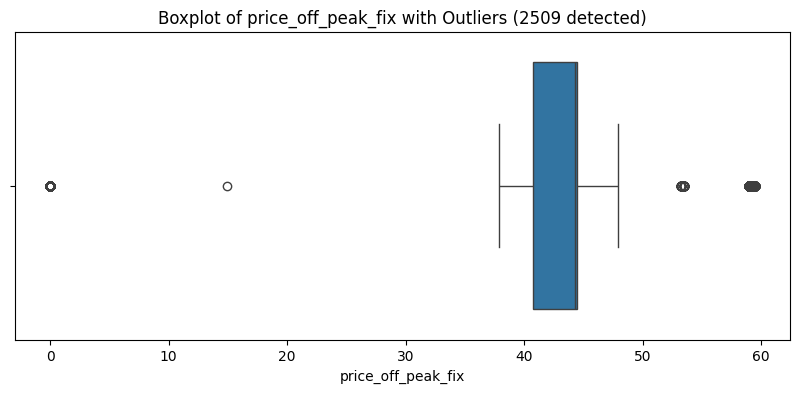


Outliers detected in 'price_off_peak_fix':


,price_off_peak_fix,churn
201,0.0,0
202,0.0,0
336,0.0,0
337,0.0,0
338,0.0,0


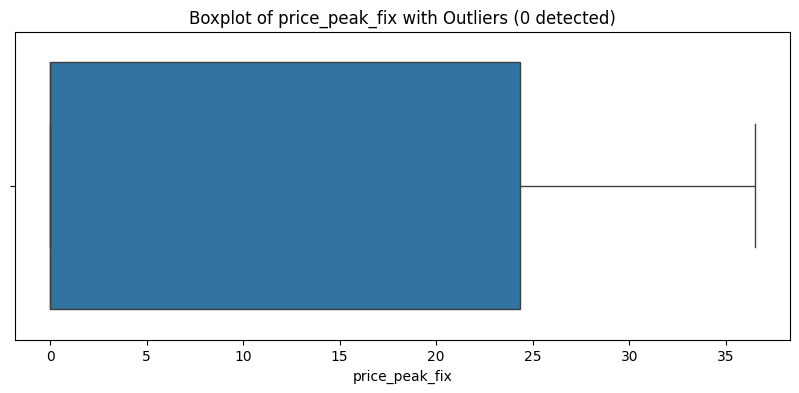


No significant outliers detected in 'price_peak_fix'.


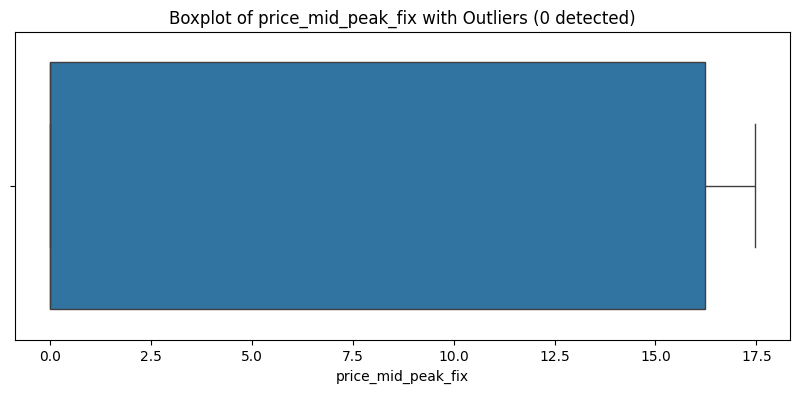


No significant outliers detected in 'price_mid_peak_fix'.


In [78]:
numeric_cols = new_df_processed.select_dtypes(include=np.number).columns.tolist()
# Exclude the target variable 'churn' from outlier analysis of features
if 'churn' in numeric_cols:
    numeric_cols.remove('churn')

print(f"Analyzing outliers for {len(numeric_cols)} numeric columns...")

for col in numeric_cols:
    detect_and_visualize_outliers(new_df_processed, col)